In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
#loading database
df = pd.read_csv("placementdata.csv")

In [3]:
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [4]:
#Checking for any missing value
df.isna().sum()

,0
StudentID,0
CGPA,0
Internships,0
Projects,0
Workshops/Certifications,0
AptitudeTestScore,0
SoftSkillsRating,0
ExtracurricularActivities,0
PlacementTraining,0
SSC_Marks,0


In [5]:
# Droping irrelevant columns
df.drop(columns=['StudentID'], inplace=True)
# converting categorical variables into boolean
label_encoders = {}
categorical_cols = ['ExtracurricularActivities', 'PlacementTraining', 'PlacementStatus']

for col in categorical_cols:
    lc = LabelEncoder()
    df[col] = lc.fit_transform(df[col])
    label_encoders[col] = lc

<ipython-input-6-36b0b37a7f44>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["PlacementStatus"], palette="coolwarm")


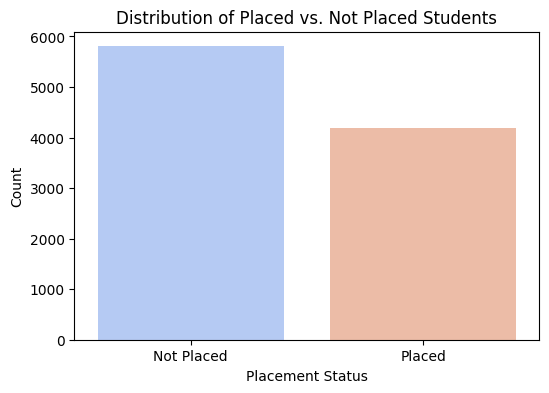

In [6]:


# Placement distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df["PlacementStatus"], palette="coolwarm")
plt.xlabel("Placement Status")
plt.ylabel("Count")
plt.title("Distribution of Placed vs. Not Placed Students")
plt.xticks(ticks=[0, 1], labels=["Not Placed", "Placed"])
plt.show()



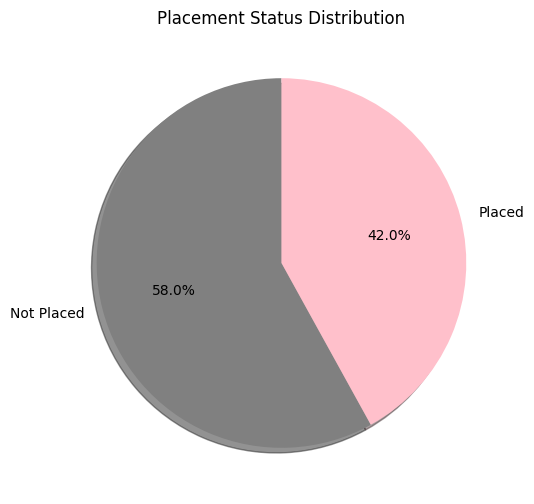

In [48]:
# Pie chart for placement status
plt.figure(figsize=(6, 6))
labels = ["Not Placed", "Placed"]
sizes = df["PlacementStatus"].value_counts()
colors = ["grey", "pink"]
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90, shadow=True)
plt.title("Placement Status Distribution")
plt.show()


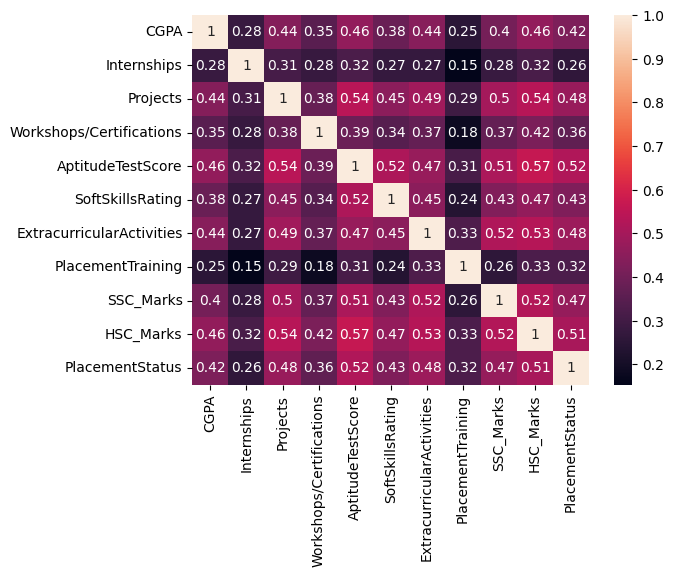

In [49]:
cm = df.corr()
sns.heatmap(cm, annot = True)
plt.show()

In [12]:
#defining x,y
X=df.drop(('PlacementStatus'),axis=1)
y=(df['PlacementStatus'])
#spliting the data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
#standardising
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [36]:
X_test

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks
6252,7.6,0,1,0,80,3.9,0,0,60,71
4684,7.5,1,1,0,81,3.8,1,1,56,58
1731,6.6,1,1,1,60,4.0,0,0,55,64
4742,8.5,1,3,2,90,4.8,1,1,88,87
4521,8.2,1,0,2,90,4.7,1,1,73,88
...,...,...,...,...,...,...,...,...,...,...
6412,7.5,1,1,0,67,3.8,0,0,66,59
8285,6.5,1,2,0,81,4.1,0,0,55,85
7853,8.4,1,3,2,90,4.8,1,1,75,87
1095,8.4,1,3,3,90,4.7,1,1,78,72


In [32]:
# Linear Regression
model_lr = LinearRegression()
from sklearn.metrics import r2_score, mean_squared_error
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
print("Linear Regression R2 Score :", r2_score(y_test, y_pred_lr))
print("Linear Regression Mean Squared Error :", mean_squared_error(y_test, y_pred_lr))


Linear Regression R2 Score : 0.4089045565616988
Linear Regression Mean Squared Error : 0.1434021189599057


In [21]:
# RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("R2 Score:" , r2_score(y_test, y_pred))
print("Mean Squared Error :", mean_squared_error(y_test, y_pred))

R2 Score: 0.38163772381008687
Mean Squared Error : 0.15001716165277776


In [29]:
# Decision Tree
model = DecisionTreeRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R2 Score: -0.14950701554797075
Mean Squared Error: 0.278875


In [33]:
# KNeighbors Regressor
model_knn = KNeighborsRegressor(n_neighbors=5)
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)
print("k-NN R2 Score:", r2_score(y_test, y_pred_knn))
print("k-NN Mean Squared Error :", mean_squared_error(y_test, y_pred_knn))

k-NN R2 Score: 0.25252675141382686
k-NN Mean Squared Error : 0.18134000000000003


In [34]:
# SVR
model_svr = SVR()
model_svr.fit(X_train, y_train)
y_pred_svr = model_svr.predict(X_test)
print("SVR R2 Score:", r2_score(y_test, y_pred_svr))
print("SVR Mean Squared Error:", mean_squared_error(y_test, y_pred_svr))

SVR R2 Score: 0.36162911521133956
SVR Mean Squared Error: 0.15487133013326823


In [27]:
# Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))



R2 Score: 0.1488186509703059
Mean Squared Error: 0.2065
Accuracy: 0.7935


In [35]:
#Logistic Regression
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


R2 Score: 0.12820893307612435
Mean Squared Error: 0.2115
Accuracy: 0.7885


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
